# Imports

In [1]:
import pandas as pd
from Fcts_Base import save_after_filtering, load_adata
from Fcts_Filtering import plot_random_organoids, filter_organoids_by

In [2]:
%load_ext autoreload
%autoreload 2

# User Input

In [3]:
load_dir = "/tachyon/scratch/gatmc/Users/kahnmaur/3_Coding/1_Analysis/2_Tables/1_FeatureExtraction_2025-07-29_10h14min12s.h5ad"
pyramid_lvl_visualization = 1
channel_visualization = 0

# Load

In [4]:
ad_raw = load_adata(load_dir)

df_raw = pd.concat([ad_raw.to_df(), ad_raw.obs.astype(str)], axis = 1)

# Filter
A variety of filter functions are examplified below. They filter objects based on a specified numerical feature range and visualize the removed organoids. To not overwrite an existing DataFrame, save the filtered DataFrame with a new name.    

### Cut organoids
Filters objects which are not completely imaged based on the fraction of the longest straight edge in the image. 

In [5]:
feat = "StraightEdge_longest" # Name of the numerical feature to filter.
lower_threshold = 0 # Lower boundary. Every object below this threshold in the feature is removed.
upper_threshold = 100 # Upper boundary. Every object above this threshold in the feature is removed.

df_filt = filter_organoids_by(ad_raw,
                    df = df_raw,
                    feature = feat, 
                    values = (lower_threshold, upper_threshold),
                    channel = channel_visualization,
                    pyramid_level = pyramid_lvl_visualization
                    )

0 objects removed due to lower boundary (0) of StraightEdge_longest.
0 objects removed due to upper boundary (100) of StraightEdge_longest.
230 objects remain after filtering.


### Low DAPI brightness

4 objects removed due to lower boundary (500) of DAPI_mean.
16 objects removed due to upper boundary (2000) of DAPI_mean.
210 objects remain after filtering.


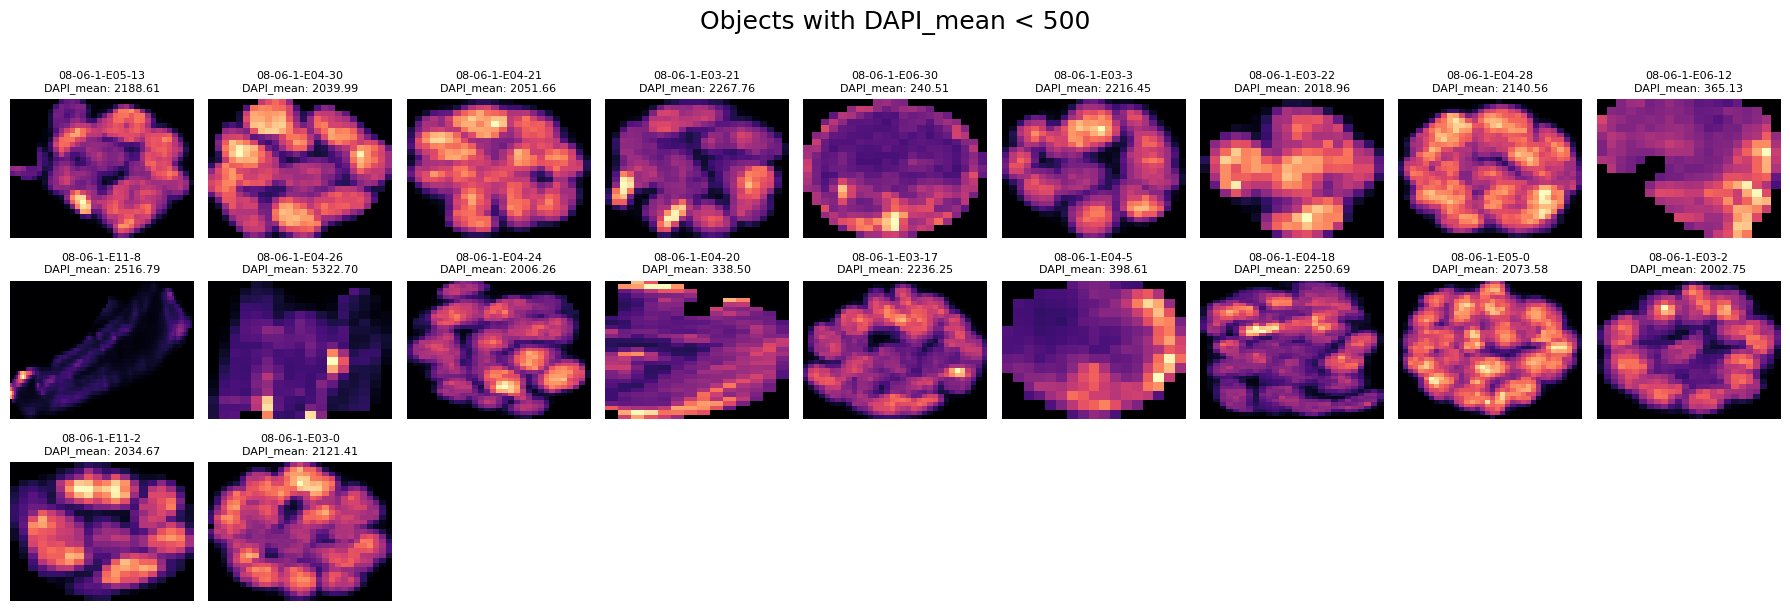

In [6]:
feat = "DAPI_mean" # Name of the numerical feature to filter.
lower_threshold = 500 # Lower boundary
upper_threshold = 2000 # Upper boundary

df_filt = filter_organoids_by(ad_raw,
                    df = df_filt,
                    feature = feat, 
                    values = (lower_threshold, upper_threshold),
                    channel = channel_visualization,
                    pyramid_level = pyramid_lvl_visualization
                    )

### Low size

183 objects removed due to lower boundary (2000) of area.
0 objects removed due to upper boundary (99999) of area.
27 objects remain after filtering.


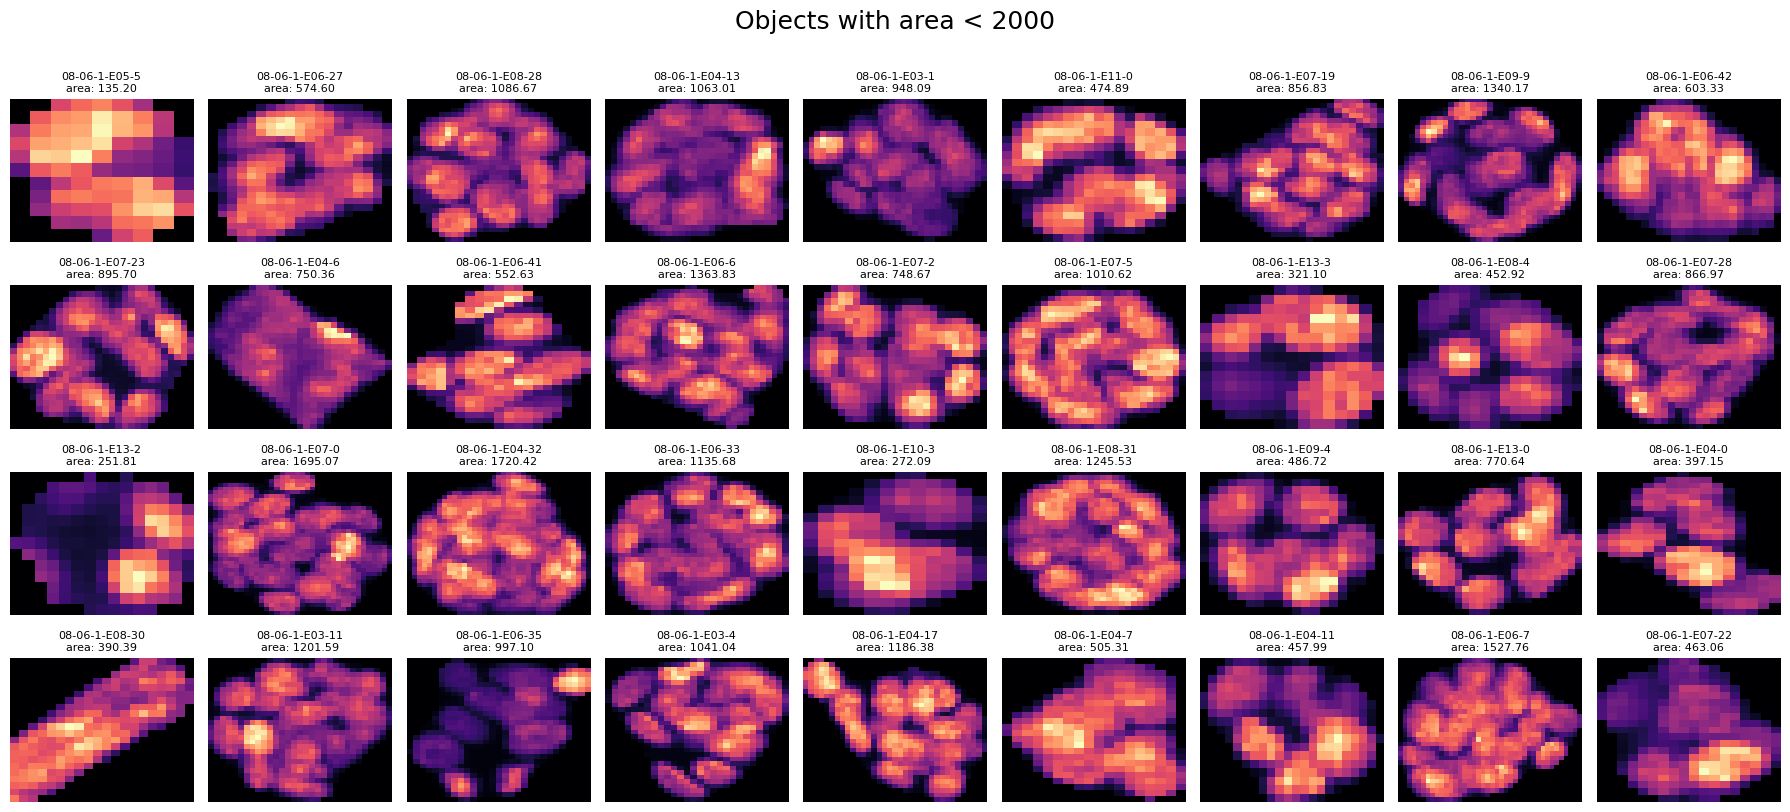

In [7]:
feat = "area" # Name of the numerical feature to filter.
lower_threshold = 2000 # Lower boundary
upper_threshold = 99999 # Upper boundary

df_filt = filter_organoids_by(ad_raw,
                    df = df_filt,
                    feature = feat, 
                    values = (lower_threshold, upper_threshold),
                    channel = channel_visualization,
                    pyramid_level = pyramid_lvl_visualization
                    )

### Sample of remaining organoids

A total of 203 objects have been removed during the filtering process. 27 objects remain for further analysis.

Only 27 objects available but grid requires 100. Adjusting grid size accordingly.


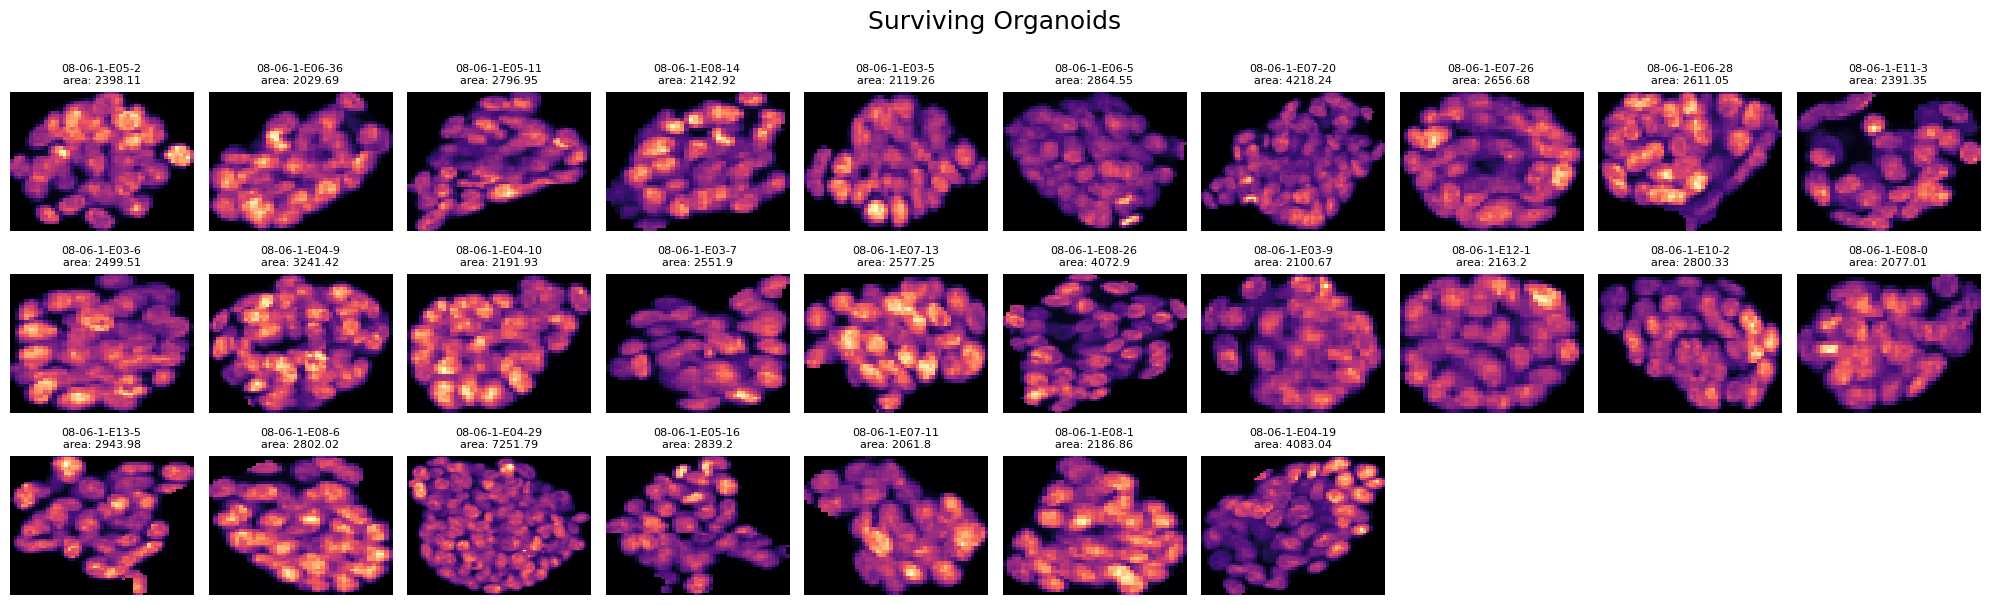

In [8]:
feature = "area" #Feature to display in title below unique ID

fig = plot_random_organoids(ad_raw,
                            df_raw = df_raw,
                            df = df_filt,
                            feature = feature,
                            rows = 10,
                            cols = 10,
                            channel = channel_visualization,
                            seed = 42,
                            pyramid_level = pyramid_lvl_visualization)

# Save DF/AD

In [9]:
save_after_filtering(
    df = df_filt,
    df_raw = df_raw,
    ad_raw = ad_raw
    )

Saved as:
/tachyon/scratch/gatmc/Users/kahnmaur/3_Coding/1_Analysis/2_Tables/2_FeaturesFiltered_2025-07-29_10h15min03s.csv
Saved as:
/tachyon/scratch/gatmc/Users/kahnmaur/3_Coding/1_Analysis/2_Tables/2_FeaturesFiltered2.h5ad
